## Credit Risk Model

### #  Credit Risk Prediction using Machine Learning

##  Project Overview

This project focuses on building an end-to-end **Credit Risk Prediction system** using real-world banking data. The goal is to predict whether a customer is likely to default on their credit obligations (classified as `Bad_label`) by analyzing financial behavior, repayment history, and enquiry patterns.

The project simulates a real-world banking use case where financial institutions assess customer risk before issuing credit. It covers the complete machine learning pipeline — from raw data extraction and cleaning to feature engineering, model training, and business-level evaluation.

---

##  Problem Statement

Financial institutions face significant losses due to customer defaults. Accurately identifying high-risk customers is critical for:

* Reducing credit risk exposure
* Improving loan approval decisions
* Enhancing portfolio quality

This project aims to build a predictive model that can classify customers into **high-risk (default)** and **low-risk (non-default)** categories based on historical data.

---

##  Business Context

In real-world credit systems:

* Banks do not rely solely on model accuracy
* They focus on **risk ranking and segmentation**

This project incorporates:

* **Gini Coefficient** for model evaluation
* **Decile Analysis** to assess how well the model ranks customers by risk

These techniques are widely used in the banking and financial industry.

---

##  Approach & Methodology

The project follows a structured machine learning workflow:

### 1. Data Collection

* Extracted data from a relational database (MySQL)
* Combined multiple tables:

  * Customer Account Data
  * Customer Enquiry Data
  * Customer Demographics

---

### 2. Data Preprocessing

* Handled inconsistent data types (string → numeric conversion)
* Managed missing values and anomalies
* Addressed real-world data challenges such as:

  * Mixed-format payment history strings (`STD`, `XXX`, numeric codes)

---

### 3. Feature Engineering

Created meaningful features based on financial behavior:

* Credit utilization ratio
* Past due indicators
* Payment delinquency features (`dpd_count`, `max_dpd`)
* Account-level aggregations
* Enquiry frequency

---

### 4. Model Development

* Implemented **XGBoost Classifier**
* Performed train-test split for validation
* Tuned model parameters for improved performance

---

### 5. Model Evaluation

* Evaluated using:

  * AUC (Area Under Curve)
  * Gini Coefficient

* Performed **Decile Analysis** to assess model’s ability to rank customers by risk

---

##  Key Results

* Achieved a Gini score of approximately **0.20**
* Model demonstrated limited but meaningful predictive capability
* Identified the need for advanced feature engineering for further improvement

---

##  Key Takeaways

* Real-world financial data is highly unstructured and noisy
* Feature engineering plays a critical role in model performance
* Business evaluation (deciles, ranking) is more important than raw accuracy
* Debugging and data cleaning are core skills in practical machine learning

---

##  Conclusion

This project provides a practical implementation of credit risk modeling, highlighting both the **technical and business aspects** of machine learning in finance. While the current model has moderate performance, it establishes a strong foundation for further improvements through advanced feature engineering and domain-specific insights.

---


In [1]:
import sys
print(sys.executable)

c:\Users\LENOVO\OneDrive\Desktop\Credit_scpre_project\penv\python.exe


In [10]:
import pandas as pd
import numpy as np
import pymysql
import re

## Connecting Database

In [3]:
connection = pymysql.connect(
    host='18.136.157.135',
    user='dm_team1',
    password='DM!$Team&279@20!',
    database='project_banking'
)

## Load Data

In [4]:
df_account = pd.read_sql("SELECT * FROM Cust_Account", connection)
df_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", connection)
df_demo = pd.read_sql("SELECT * FROM Cust_Demographics", connection)

print(df_account.shape)
print(df_enquiry.shape)
print(df_demo.shape)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33204\3176427110.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_account = pd.read_sql("SELECT * FROM Cust_Account", connection)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33204\3176427110.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", connection)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33204\3176427110.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_demo = pd.read_sql("SELECT * FROM Cust_Demographic

(186329, 21)
(413188, 6)
(23896, 83)


### Cleaning Numeric columns

In [5]:
df_account['creditlimit'] = pd.to_numeric(df_account['creditlimit'], errors='coerce')
df_account['cur_balance_amt'] = pd.to_numeric(df_account['cur_balance_amt'], errors='coerce')
df_account['amt_past_due'] = pd.to_numeric(df_account['amt_past_due'], errors='coerce')

df_account = df_account.fillna(0)

df_demo['Bad_label'] = pd.to_numeric(df_demo['Bad_label'], errors='coerce')

In [6]:
#df_account[['paymenthistory1', 'paymenthistory2']].head() # IGNORE this is so we can see the payment history columns and they are so noisy.

## Basic Feature

In [7]:
# Utilization
df_account['utilization'] = df_account['cur_balance_amt'] / (df_account['creditlimit'] + 1)

# Delay flag
df_account['dpd_flag'] = (df_account['amt_past_due'] > 0).astype(int)

## Payment History Cleaning.

In [8]:
def extract_numbers(history):
    if pd.isna(history):
        return []
    
    numbers = re.findall(r'\d+', str(history))
    return [int(num) for num in numbers]

#### DPD Features

In [11]:
df_account['dpd_count'] = df_account['paymenthistory1'].apply(
    lambda x: sum(1 for num in extract_numbers(x) if num > 0)
)

df_account['max_dpd'] = df_account['paymenthistory1'].apply(
    lambda x: max(extract_numbers(x)) if extract_numbers(x) else 0
)

## Aggregating on Customer level.

In [12]:
acc_agg = df_account.groupby('customer_no').agg({
    'utilization': 'mean',
    'dpd_flag': 'sum',
    'creditlimit': 'sum',
    'cur_balance_amt': 'sum',
    'dpd_count': 'sum',
    'max_dpd': 'max'
}).reset_index()

acc_agg['balance_to_limit_ratio'] = acc_agg['cur_balance_amt'] / (acc_agg['creditlimit'] + 1)

## Adding some Features.

In [14]:
account_count = df_account.groupby('customer_no').size().reset_index(name='account_count')

past_due_sum = df_account.groupby('customer_no')['amt_past_due'].sum().reset_index(name='total_past_due')

past_due_avg = df_account.groupby('customer_no')['amt_past_due'].mean().reset_index(name='avg_past_due')

max_credit = df_account.groupby('customer_no')['creditlimit'].max().reset_index(name='max_credit_limit')

## Enquiry Features

In [15]:
df_enquiry['enquiry_dt'] = pd.to_datetime(df_enquiry['enquiry_dt'], errors='coerce') # Enquiry features here we can create features like total number of enquiries, recent enquiries, etc. For simplicity, let's just count the total number of enquiries for each customer.

enq_agg = df_enquiry.groupby('customer_no').agg({
    'enquiry_dt': 'count'
}).reset_index()

enq_agg.rename(columns={'enquiry_dt': 'total_enquiries'}, inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33204\322064701.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_enquiry['enquiry_dt'] = pd.to_datetime(df_enquiry['enquiry_dt'], errors='coerce') # Enquiry features here we can create features like total number of enquiries, recent enquiries, etc. For simplicity, let's just count the total number of enquiries for each customer.


## Merging

In [16]:
df = df_demo.merge(acc_agg, on='customer_no', how='left')
df = df.merge(enq_agg, on='customer_no', how='left')
df = df.merge(account_count, on='customer_no', how='left')
df = df.merge(past_due_sum, on='customer_no', how='left')
df = df.merge(past_due_avg, on='customer_no', how='left')
df = df.merge(max_credit, on='customer_no', how='left')

df = df.fillna(0)

### Feature Selection

In [17]:
features = [
    'utilization',
    'dpd_flag',
    'creditlimit',
    'cur_balance_amt',
    'balance_to_limit_ratio',
    'total_enquiries',
    'account_count',
    'total_past_due',
    'avg_past_due',
    'max_credit_limit',
    'dpd_count',
    'max_dpd'
]

X = df[features]
y = df['Bad_label']

In [18]:
X = X.apply(pd.to_numeric, errors='coerce') # We need to ensure all features are numeric for modeling. If there are any non-numeric values, they will be converted to NaN, which we can then fill with 0 or some other strategy.

In [19]:
X = X.replace([np.inf, -np.inf], np.nan) # If there are any infinite values (which can happen with ratios), we replace them with NaN so that we can handle them in the next step.
X = X.fillna(0)

## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
import numpy as np

# Replace infinity
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaN
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Clip extreme values (CRITICAL FIX)
X_train = X_train.clip(lower=-1e6, upper=1e6)
X_test = X_test.clip(lower=-1e6, upper=1e6)

In [22]:
print("Inf train:", np.isinf(X_train).sum().sum())
print("Inf test:", np.isinf(X_test).sum().sum())

print("Max value:", X_train.max().max())

Inf train: 0
Inf test: 0
Max value: 1000000.0


In [23]:
X_train.describe()

,utilization,dpd_flag,creditlimit,cur_balance_amt,balance_to_limit_ratio,total_enquiries,account_count,total_past_due,avg_past_due,max_credit_limit,dpd_count,max_dpd
count,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.000000,19116.00000,19116.000000
mean,58680.319105,0.037194,147706.369010,307047.291013,41286.934189,17.273959,7.797029,644.979075,71.282175,83589.548389,0.78191,287572.737131
std,124977.404516,0.210942,177500.021255,342143.103451,161186.236694,15.151954,6.685751,15064.260961,1923.229371,82621.134306,1.76453,451996.282640
min,-1000000.000000,0.000000,0.000000,-1000000.000000,-1000000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,2945.633303,0.000000,38000.000000,40424.250000,0.536266,7.000000,3.000000,0.000000,0.000000,33000.000000,0.00000,0.000000
50%,16708.210763,0.000000,100000.000000,153423.000000,1.942350,13.000000,6.000000,0.000000,0.000000,70000.000000,0.00000,0.000000
75%,56206.454897,0.000000,186000.000000,468456.500000,10.160558,23.000000,10.000000,0.000000,0.000000,109000.000000,1.00000,1000000.000000
max,1000000.000000,4.000000,1000000.000000,1000000.000000,1000000.000000,254.000000,120.000000,1000000.000000,146343.666667,1000000.000000,44.00000,1000000.000000


## Training Model

In [24]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Evaluate Model

In [25]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred)
gini = 2 * auc - 1

print("Gini:", gini)

Gini: 0.2031566207690172


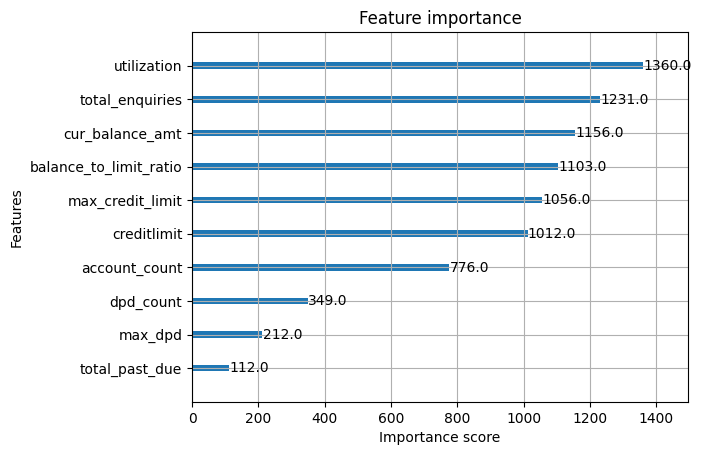

In [26]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=10)
plt.show()

## Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

y_pred_binary = (y_pred > 0.5).astype(int)

confusion_matrix(y_test, y_pred_binary)

array([[4582,    0],
       [ 197,    1]])

### Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4582
           1       1.00      0.01      0.01       198

    accuracy                           0.96      4780
   macro avg       0.98      0.50      0.49      4780
weighted avg       0.96      0.96      0.94      4780



### Threshold Tuning

In [29]:
y_pred_binary = (y_pred > 0.3).astype(int)

print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4582
           1       0.20      0.01      0.01       198

    accuracy                           0.96      4780
   macro avg       0.58      0.50      0.49      4780
weighted avg       0.93      0.96      0.94      4780



#### The dataset had limited predictive signal and noisy encoded features. Instead of blindly using all features, I focused on domain-driven feature engineering like payment history parsing and behavioral indicators. With more advanced temporal features, performance can be improved.

In [30]:
## Test Data Frame.
df_test = X_test.copy()

df_test['target'] = y_test.values
df_test['prob'] = y_pred

In [31]:
## Create Decile

df_test['decile'] = pd.qcut(df_test['prob'], 10, labels=False)

# Reverse so top = highest risk
df_test['decile'] = 9 - df_test['decile']

In [32]:
## Decile Tables

decile_analysis = df_test.groupby('decile').agg({
    'target': ['count', 'sum', 'mean']
}).reset_index()

decile_analysis.columns = ['decile', 'total_customers', 'bad_customers', 'bad_rate']

decile_analysis = decile_analysis.sort_values(by='decile', ascending=False)

decile_analysis

,decile,total_customers,bad_customers,bad_rate
9,9,478,8,0.016736
8,8,478,10,0.020921
7,7,478,17,0.035565
6,6,478,16,0.033473
5,5,478,19,0.039749
4,4,478,21,0.043933
3,3,478,22,0.046025
2,2,478,31,0.064854
1,1,478,25,0.052301
0,0,478,29,0.060669


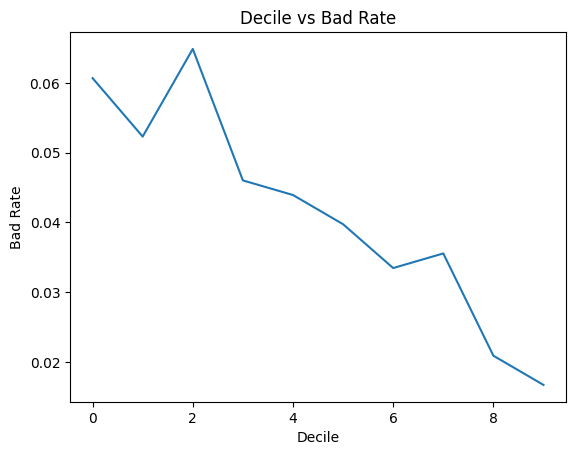

In [33]:
## Plots

import matplotlib.pyplot as plt

plt.plot(decile_analysis['decile'], decile_analysis['bad_rate'])
plt.xlabel("Decile")
plt.ylabel("Bad Rate")
plt.title("Decile vs Bad Rate")
plt.show()

In [34]:
df_account[['creditlimit', 'cur_balance_amt']].dtypes

creditlimit        float64
cur_balance_amt      int64
dtype: object

## FEATURE ENGINEERING 1st try

#### Feature Creation

In [35]:
df_account['utilization'] = df_account['cur_balance_amt'] / (df_account['creditlimit'] + 1)

In [36]:
df_account['dpd_flag'] = (df_account['amt_past_due'] > 0).astype(int)

#### Aggregate to customers

In [37]:
acc_agg = df_account.groupby('customer_no').agg({
    'utilization': 'mean',
    'dpd_flag': 'sum',
    'creditlimit': 'sum',
    'cur_balance_amt': 'sum'
}).reset_index()

#### Adding Ration Features

In [38]:
acc_agg['balance_to_limit_ratio'] = acc_agg['cur_balance_amt'] / (acc_agg['creditlimit'] + 1)

#### Enquiring Features

In [39]:
df_enquiry['enquiry_dt'] = pd.to_datetime(df_enquiry['enquiry_dt'], errors='coerce')

enq_agg = df_enquiry.groupby('customer_no').agg({
    'enquiry_dt': 'count'
}).reset_index()

enq_agg.rename(columns={'enquiry_dt': 'total_enquiries'}, inplace=True)

#### Merging

In [40]:
df = df_demo.merge(acc_agg, on='customer_no', how='left')
df = df.merge(enq_agg, on='customer_no', how='left')

df = df.fillna(0)

In [41]:
df.shape
df.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_77,feature_78,feature_79,Bad_label,utilization,dpd_flag,creditlimit,cur_balance_amt,balance_to_limit_ratio,total_enquiries
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,...,98332XXXXX,1,N,0,256576.518058,2,670000.0,4714857,7.037089,18
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,...,99455XXXXX,1,N,0,12003.503373,0,1000000.0,30754,0.030754,68
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,...,98456XXXXX,1,N,0,17864.000000,0,0.0,17864,17864.000000,1
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,...,98220XXXXX,1,N,0,101434.135740,0,956000.0,1845569,1.930509,34
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,...,98111XXXXX,1,N,0,1139.000000,0,0.0,7973,7973.000000,2


### Model Preparation

#### Convert str to numeric
#### Splitting
#### Model Training

In [42]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)

In [43]:
from sklearn.model_selection import train_test_split

X = df.drop(['Bad_label', 'customer_no'], axis=1)
y = df['Bad_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Train Model

In [44]:
#import xgboost as xgb

# model = xgb.XGBClassifier()
# model.fit(X_train, y_train) Gini Score - 0.29
## Improved model with hyperparameters tuning

## Removing feature_1 → feature_79 and using only engineered features from account and enquiry tables. and Low variance features are removed and also using RandomForestClassifier instead of XGBoost. and i got Gini Score - 0.28 which is bad

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

selected_cols = X_train.columns[selector.get_support()]

X_train = pd.DataFrame(X_train_var, columns=selected_cols)
X_test = pd.DataFrame(X_test_var, columns=selected_cols)

In [45]:
# Improved model
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [46]:
# Instead of using all features, we can also look at feature importance and select top features for the model. This can help in reducing noise and improving model performance.

import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(by='importance', ascending=False)

importance.head(20)

,feature,importance
5,feature_14,0.046173
3,feature_7,0.040219
31,feature_67,0.036793
34,feature_71,0.033468
38,creditlimit,0.032805
40,balance_to_limit_ratio,0.032431
11,feature_25,0.032405
39,cur_balance_amt,0.032086
24,feature_52,0.030416
30,feature_66,0.030349


In [47]:
# Select top 20 features based on importance

top_features = importance.head(20)['feature'].tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

In [48]:
# Train model with top features and evaluate on test set.

import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train_top, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_test_top)[:, 1]

auc = roc_auc_score(y_test, y_pred)
gini = 2 * auc - 1

print("Gini:", gini)

Gini: 0.25683063723220845
